In [1]:
import os
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
import utility as ut
from scipy.stats import norm
os.chdir('/Users/ngdnh/Codespace/unifiedPPS/')

%config InlineBackend.figure_formats = ['svg']

# Find $\lambda_j$ from Rabi oscillations

In [2]:
def add_pulse(pulse_train, pulse_name, start, tg, sigma, A):
    """
    Add a pulse to the pulse train.
    """
    pulse_train[pulse_name] = {'start': start, 'tg': tg, 'sigma': sigma, 'A': A}
    pulse_train['clock'] = pulse_train['clock']+tg

def V_d(t, args):
    """ 
    Gaussian pulse function for the Hamiltonian.
    """
    for item, pulse_specs in args.items():
        if item == 'clock':
            continue
        if t <= pulse_specs['start'] or t >= (pulse_specs['start'] + pulse_specs['tg']):
            continue
        else:
            t_local = t
            t_local += -pulse_specs['start']
            return pulse_specs['A'] * (np.exp(-(t_local-pulse_specs['tg']/2)**2/(2*pulse_specs['sigma']**2)) - np.exp(-pulse_specs['tg']**2/(8*pulse_specs['sigma']**2))) \
                / (1-np.exp(-pulse_specs['tg']**2/(8*pulse_specs['sigma']**2)))
    return 0

In [3]:
pulse_train = {'clock': 0}
add_pulse(pulse_train, pulse_name='pi/2_01', start=pulse_train['clock'], tg=60, sigma=60/4, A=0.17576112663101393)
add_pulse(pulse_train, pulse_name='pi/2_12', start=pulse_train['clock'], tg=20, sigma=20/4, A=0.2361)

pulse_train

{'clock': 80,
 'pi/2_01': {'start': 0, 'tg': 60, 'sigma': 15.0, 'A': 0.17576112663101393},
 'pi/2_12': {'start': 60, 'tg': 20, 'sigma': 5.0, 'A': 0.2361}}

### Check rotated angle

In [40]:
pulse_90_01 = {'clock': 0}
add_pulse(pulse_90_01, pulse_name='pi/2_01', start=pulse_90_01['clock'], tg=60, sigma=60/4, A=0.0978)

pulse_90_12 = {'clock': 0}
add_pulse(pulse_90_12, pulse_name='pi/2_12', start=pulse_90_12['clock'], tg=20, sigma=20/4, A=0.21213132423456989)

def gaussian_for_integration(t):
    return V_d(t, args)

In [43]:
from scipy.integrate import quad

args = pulse_90_01
area, error = quad(gaussian_for_integration, 0, 100)

print(f"Numerically calculated area under the Gaussian curve: {area*0.5001:.10f}")

Numerically calculated area under the Gaussian curve: 1.5707271782


In [33]:
args = pulse_90_12
area, error = quad(gaussian_for_integration, 0, 100) 

print(f"Numerically calculated area under the Gaussian curve: {area*0.6917215080582997:.10f}")

Numerically calculated area under the Gaussian curve: 1.5707963268


## Compare to real Rabi oscillations

In [9]:
IQdata_rabi12 = np.load('./data/rabi12/iq_data.pkl', allow_pickle=True)
params_rabi12 = np.load('./data/rabi12/params.pkl', allow_pickle=True)

In [11]:
amplitude_sweep = np.linspace(params_rabi12['infimum'], params_rabi12['supremum'], params_rabi12['num_points'])
real_avg_iq = [np.real(np.average(IQdata_rabi12[idx])) for idx in range(params_rabi12['num_points'])]

### Plot disciminator

In [19]:
ansatz_amp = 1.5
outliers = 1

popt, yfit, pcov = ut.fit_function(
    amplitude_sweep[outliers:-outliers],
    real_avg_iq[outliers:-outliers],
    lambda x, A, T, phi, B: A * np.cos(2 * np.pi / T * x + phi) + B,
    [30, ansatz_amp, 0, 0]
)

idx_amp_zero = np.argmin(real_avg_iq)
idx_amp_two = np.argmax(real_avg_iq)
distance_zero_two = ut.distance(real_avg_iq[idx_amp_zero], real_avg_iq[idx_amp_two])

def post_select(IQ_data, threshold, select_if_greater=True):
    selected, rejected, rejected_indices = [], [], []
    for idx, point in enumerate(IQ_data):
        condition = np.real(point) > threshold if select_if_greater else np.real(point) < threshold
        if condition:
            selected.append(point)
        else:
            rejected.append(point)
            rejected_indices.append(idx)
    return selected, rejected, rejected_indices

threshold_0 = real_avg_iq[idx_amp_zero] + distance_zero_two / 2
IQdata_0_post_selected, IQdata_0_post_rejected, _ = post_select(IQdata_rabi12[idx_amp_zero], threshold_0, select_if_greater=False)

threshold_2 = real_avg_iq[idx_amp_two] - distance_zero_two / 2
IQdata_2_post_selected, IQdata_2_post_rejected, _ = post_select(IQdata_rabi12[idx_amp_two], threshold_2, select_if_greater=True)

x = np.linspace(-100, 100, 100)
mu0_ps, std0_ps = norm.fit(np.real(IQdata_0_post_selected))
mu2_ps, std2_ps = norm.fit(np.real(IQdata_2_post_selected))
p0_ps = norm.pdf(x, mu0_ps, std0_ps)
p2_ps = norm.pdf(x, mu2_ps, std2_ps)

cluster_0_mean = np.mean(IQdata_0_post_selected)
cluster_2_mean = np.mean(IQdata_2_post_selected)
radius_fit = ut.distance(cluster_0_mean, cluster_2_mean) / 2

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(6, 6))

axes[0, 0].hist(np.real(IQdata_rabi12[idx_amp_zero]), bins=100, density=True, color='red', alpha=0.5)
axes[0, 0].plot(x, p0_ps, 'k', linewidth=1)
axes[0, 0].set_aspect('auto')

axes[0, 1].scatter(np.real(IQdata_0_post_selected), np.imag(IQdata_0_post_selected), s=3, alpha=0.2, color='red')
axes[0, 1].scatter(np.real(IQdata_0_post_rejected), np.imag(IQdata_0_post_rejected), s=3, alpha=0.2, color='gray')
axes[0, 1].set_xlim([-100, 100])
axes[0, 1].set_ylim([-50, 150])
axes[0, 1].set_aspect('equal')

axes[1, 0].hist(np.real(IQdata_rabi12[idx_amp_two]), bins=100, density=True, color='blue', alpha=0.5)
axes[1, 0].plot(x, p2_ps, 'k', linewidth=1)
axes[1, 0].set_aspect('auto')

axes[1, 1].scatter(np.real(IQdata_2_post_selected), np.imag(IQdata_2_post_selected), s=3, alpha=0.2, color='blue')
axes[1, 1].scatter(np.real(IQdata_2_post_rejected), np.imag(IQdata_2_post_rejected), s=3, alpha=0.2, color='gray', label=f'{len(IQdata_2_post_rejected)}')
axes[1, 1].set_xlim([-100, 100])
axes[1, 1].set_ylim([-50, 150])
axes[1, 1].set_aspect('equal')
axes[1, 1].legend()

fig.tight_layout()

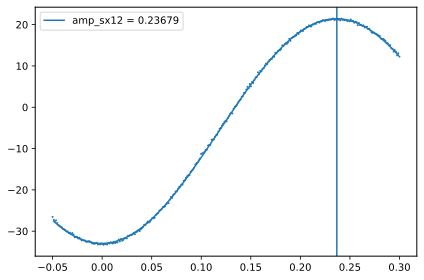

In [22]:
fig, ax = plt.subplots(figsize=(6,4))
amplitude_sweep_outlier = amplitude_sweep[outliers:-outliers]
ax.scatter(amplitude_sweep, real_avg_iq, s=1)
ax.plot(amplitude_sweep_outlier, yfit)
ax.axvline(amplitude_sweep_outlier[np.argmax(yfit)], label=f'amp_sx12 = {np.round(amplitude_sweep_outlier[np.argmax(yfit)], 5)}')
ax.legend()
fig.tight_layout()